# 01 — EDA (Exploratory Data Analysis)


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

# Configuración

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DIR_BASE = "Datos/Transformados"

DATA_PATH = "./Datos/Originales/01_Optimización/Opt_dataset_4Objectives_CC.csv"

OUT_DIR = os.path.join(DIR_BASE, 'Optimizacion', "eda")
FIG_DIR = os.path.join(OUT_DIR, "figures")

# Crear carpetas automáticamente si no existen
os.makedirs(DIR_BASE, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## 1) Carga del dataset

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head())
print("Columns:", df_raw.columns.tolist())


Shape: (1700, 10)


,x1,x2,x3,x4,x5,x6,y1,y2,y3,y4
0,3.2,0.95,1.2,2.4,46.5,5.1,7.543477,0.000590,-0.809682,0.002764
1,1.2,0.95,1.0,0.1,45.0,4.8,5.377060,0.206311,-0.918555,0.225746
2,1.2,0.75,1.3,0.4,48.0,4.8,5.048992,0.033728,-0.908788,0.060608
3,1.4,0.85,0.8,0.1,49.0,4.7,5.681045,0.238174,-0.917285,0.244254
4,1.2,0.90,2.0,0.1,45.0,4.8,5.177121,0.016478,-0.914834,0.054130


Columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y1', 'y2', 'y3', 'y4']


## 2) Mapeo de columnas y renombrado


In [5]:
X_cols_1 = ["x1", "x2", "x3", "x4", "x5", "x6"]
Y_cols_1 = ["y1", "y2", "y3", "y4"]

renombrar = {
    "x1": "hm",
    "x2": "alpha_m",
    "x3": "er",
    "x4": "dsi",
    "x5": "bst",
    "x6": "bss",
    "y1": "TC",
    "y2": "TcogPP",
    "y3": "ned",
    "y4": "TriPP"
}

faltantes = [c for c in X_cols_1 + Y_cols_1 if c not in df_raw.columns]
assert not faltantes, f"Faltan columnas esperadas en el CSV: {faltantes}"

df = df_raw.rename(columns=renombrar).copy()

X_cols = [renombrar[c] for c in X_cols_1]
Y_cols = [renombrar[c] for c in Y_cols_1]

# Dataset base solo con variables de entrada y salida
df_xy = df[X_cols + Y_cols].copy()

# Sustituir inf por NaN
df_xy.replace([np.inf, -np.inf], np.nan, inplace=True)

# Limpiar solo NaN/Inf, manteniendo duplicados
filas_antes = len(df_xy)
df_xy.dropna(inplace=True)
filas_despues = len(df_xy)

print("X_cols:", X_cols)
print("Y_cols:", Y_cols)
print(f"Filas eliminadas por NaN/Inf: {filas_antes - filas_despues}")
print(f"Filas restantes tras limpieza básica: {filas_despues}")

display(df_xy.head())

X_cols: ['hm', 'alpha_m', 'er', 'dsi', 'bst', 'bss']
Y_cols: ['TC', 'TcogPP', 'ned', 'TriPP']
Filas eliminadas por NaN/Inf: 0
Filas restantes tras limpieza básica: 1700


,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP
0,3.2,0.95,1.2,2.4,46.5,5.1,7.543477,0.000590,-0.809682,0.002764
1,1.2,0.95,1.0,0.1,45.0,4.8,5.377060,0.206311,-0.918555,0.225746
2,1.2,0.75,1.3,0.4,48.0,4.8,5.048992,0.033728,-0.908788,0.060608
3,1.4,0.85,0.8,0.1,49.0,4.7,5.681045,0.238174,-0.917285,0.244254
4,1.2,0.90,2.0,0.1,45.0,4.8,5.177121,0.016478,-0.914834,0.054130


## 3) Limpieza básica
- Nos quedamos solo con `X` y `Y`.
- Eliminamos NaN/Inf.
- Eliminamos duplicados exactos (opcional, pero ayuda).

In [6]:
df_xy = df[X_cols + Y_cols].copy()

# Reemplazar inf por NaN
df_xy.replace([np.inf, -np.inf], np.nan, inplace=True)

# Eliminar solo NaN/Inf
filas_antes = len(df_xy)
df_xy.dropna(inplace=True)
filas_despues = len(df_xy)

print(f"Eliminamos NaN/Inf: {filas_antes - filas_despues} -> restantes: {filas_despues}")

# Observar duplicados exactos, pero NO eliminarlos
n_duplicados = df_xy.duplicated().sum()
print(f"Duplicados exactos detectados (se mantienen): {n_duplicados}")

display(df_xy.describe().T)

Eliminamos NaN/Inf: 0 -> restantes: 1700
Duplicados exactos detectados (se mantienen): 395


,count,mean,std,min,25%,50%,75%,max
hm,1700.0,2.161765,1.106701,1.000000,1.200000,1.600000,3.200000,4.000000
alpha_m,1700.0,0.858353,0.096439,0.700000,0.750000,0.900000,0.900000,1.000000
er,1700.0,1.404647,0.414633,0.600000,1.100000,1.400000,1.800000,2.000000
dsi,1700.0,0.993353,0.951618,0.000000,0.100000,0.700000,2.100000,2.500000
bst,1700.0,46.152941,1.129553,45.000000,45.000000,46.000000,46.500000,49.500000
bss,1700.0,4.729353,0.546747,3.500000,4.700000,4.800000,5.100000,5.900000
TC,1700.0,6.190064,1.264042,4.458092,5.066071,5.843123,7.304702,9.711661
TcogPP,1700.0,0.075674,0.078890,0.000192,0.011795,0.042945,0.126224,0.554274
ned,1700.0,-0.881333,0.050642,-0.921898,-0.917778,-0.909961,-0.852903,-0.662504
TriPP,1700.0,0.090869,0.083438,0.001375,0.024685,0.061183,0.152218,0.513019


## 4) Distribuciones (histogramas rápidos)

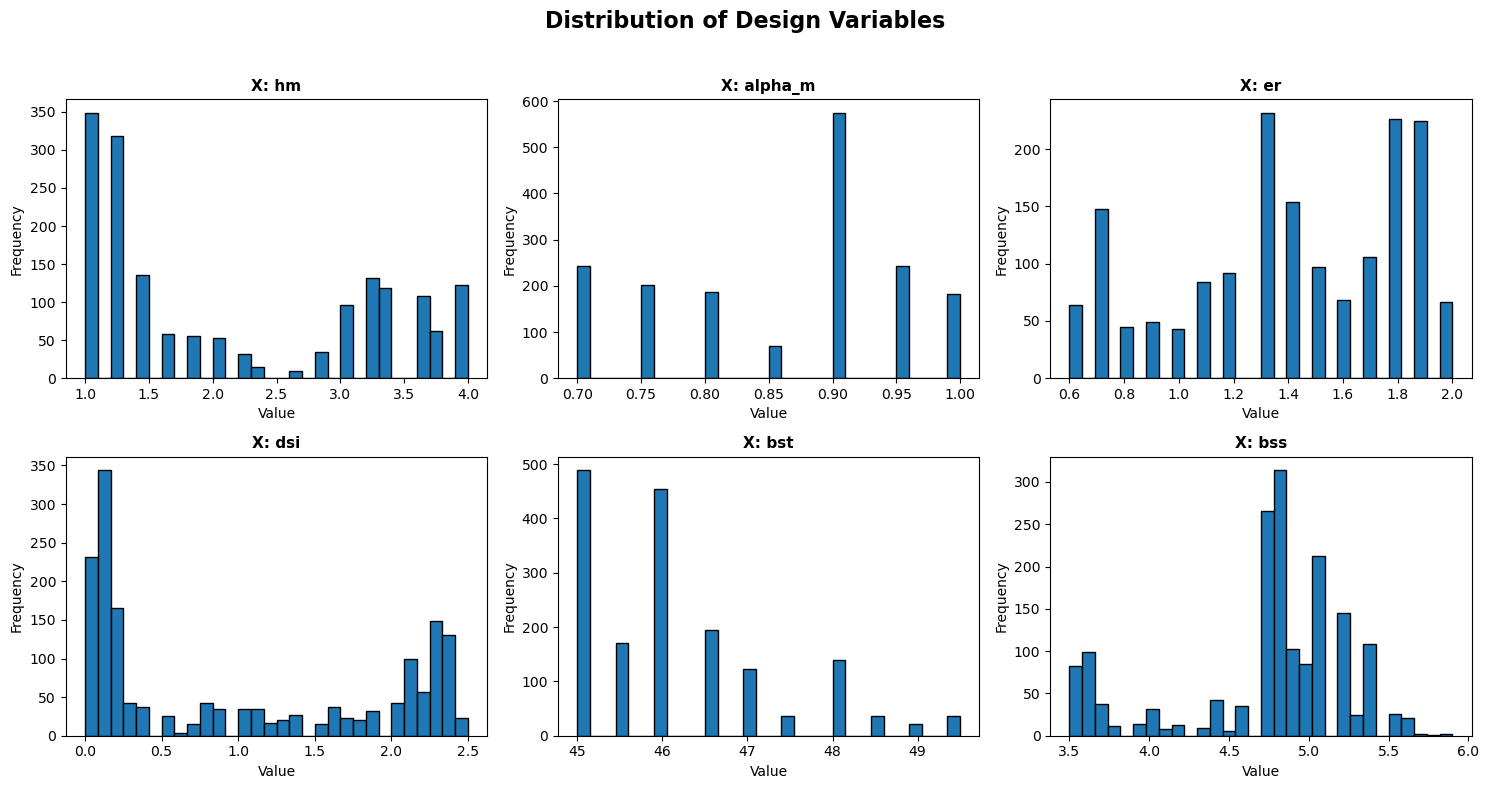

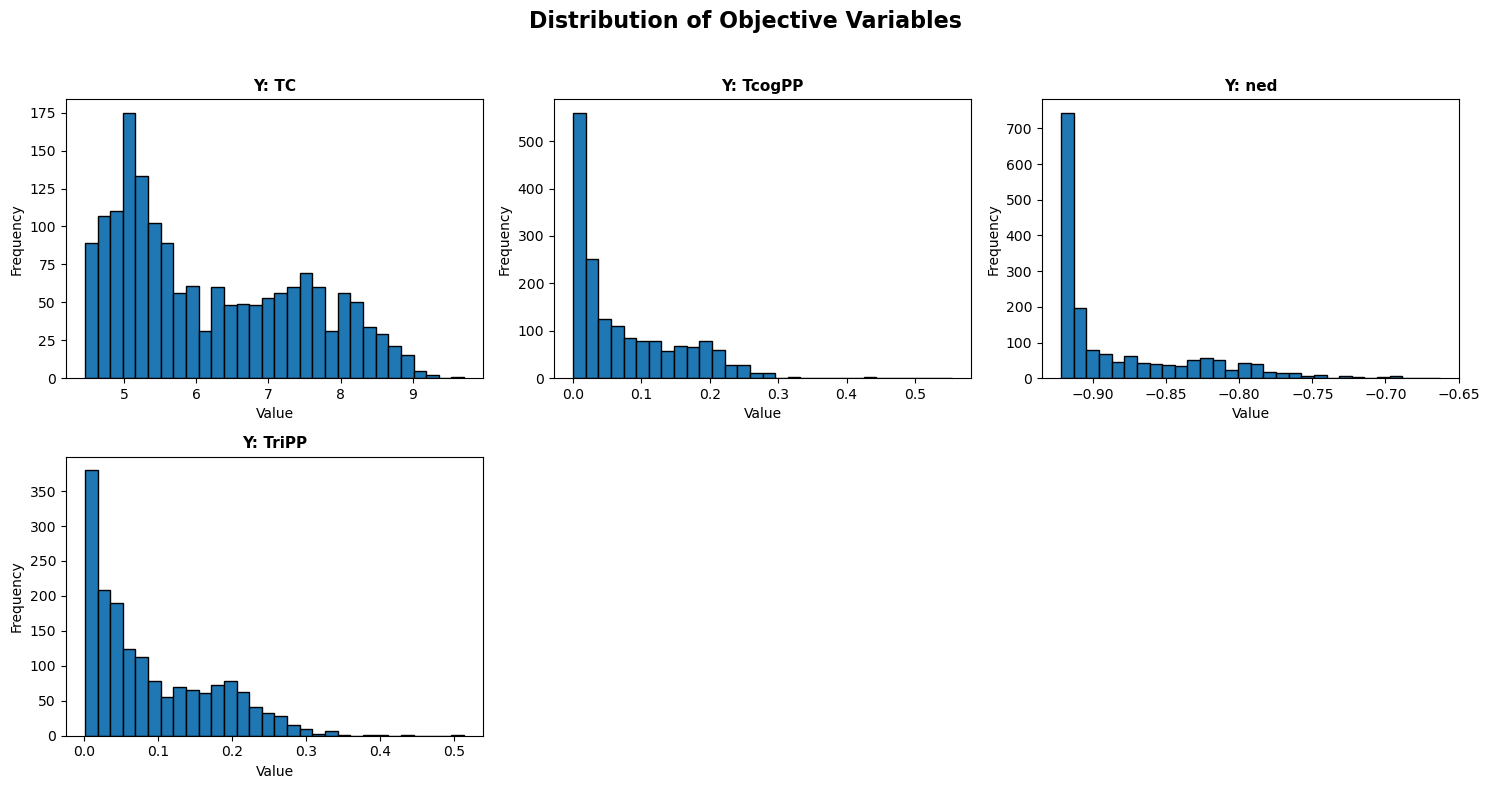

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def histogramas_rapidos(df_in, columnas, bins=30,
                        prefijo_titulo="",
                        titulo_general="Distribution of Variables"):

    n = len(columnas)
    ncols = 3
    nfilas = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nfilas,
        ncols,
        figsize=(15, 4 * nfilas)
    )

    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columnas):
        axes[i].hist(
            df_in[col].values,
            bins=bins,
            edgecolor="black"
        )

        axes[i].set_title(
            f"{prefijo_titulo}{col}",
            fontsize=11,
            fontweight="bold"
        )

        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    # Eliminar subplots vacíos si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Título general bonito
    fig.suptitle(
        titulo_general,
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Histogramas variables de diseño
histogramas_rapidos(
    df_xy,
    X_cols,
    prefijo_titulo="X: ",
    titulo_general="Distribution of Design Variables"
)

# Histogramas variables objetivo
histogramas_rapidos(
    df_xy,
    Y_cols,
    prefijo_titulo="Y: ",
    titulo_general="Distribution of Objective Variables"
)

## 5) Correlaciones


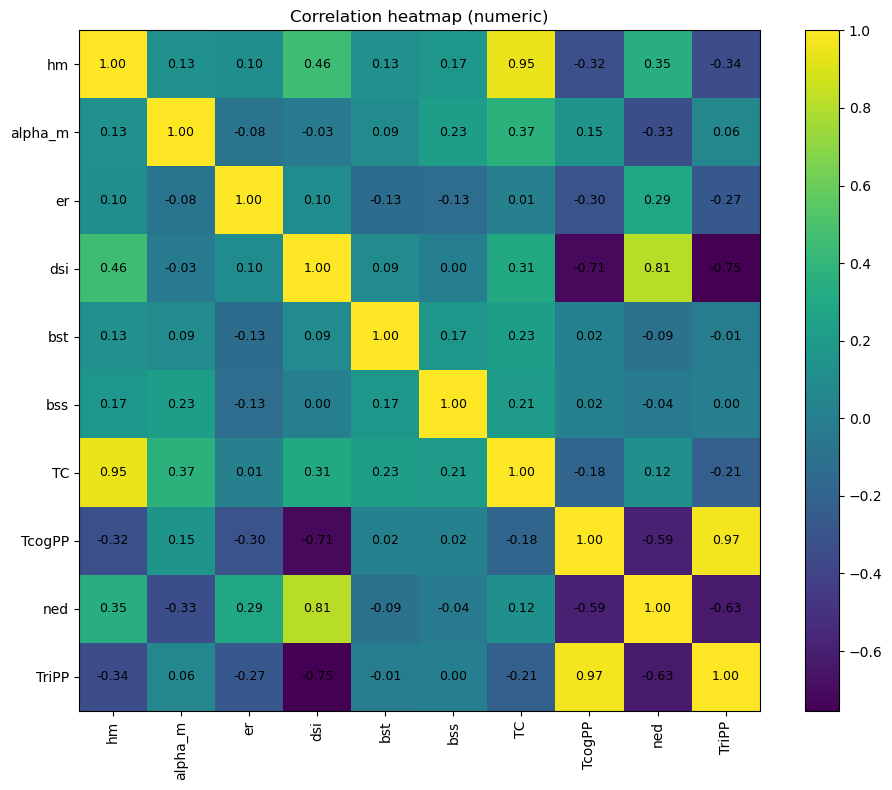

Saved: Datos/Transformados\Optimizacion\eda\corr_matrix.csv


In [8]:
corr = df_xy.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr.values)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Añadir valores dentro de cada celda
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.values[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=9)

plt.title("Correlation heatmap (numeric)")
plt.colorbar()
plt.tight_layout()
plt.show()

corr_path = os.path.join(OUT_DIR, "corr_matrix.csv")
corr.to_csv(corr_path, index=True)
print("Saved:", corr_path)

## 6) Pareto del dataset (soluciones no dominadas)


In [9]:
def mascara_pareto(Y: np.ndarray) -> np.ndarray:
    """Máscara booleana de soluciones no dominadas (Pareto) para minimización."""
    n = Y.shape[0]
    es_no_dominado = np.ones(n, dtype=bool)

    for i in range(n):
        if not es_no_dominado[i]:
            continue

        domina_i = np.all(Y <= Y[i], axis=1) & np.any(Y < Y[i], axis=1)
        domina_i[i] = False

        if np.any(domina_i):
            es_no_dominado[i] = False

    return es_no_dominado


Y = df_xy[Y_cols].values

mask_nd = mascara_pareto(Y)
pareto_df = df_xy.loc[mask_nd].copy()

print("Pareto:", pareto_df.shape[0], "de", df_xy.shape[0])
display(pareto_df.head())

pareto_path = os.path.join(OUT_DIR, "pareto_from_dataset.csv")
pareto_df.to_csv(pareto_path, index=False)

print("Saved:", pareto_path)

Pareto: 410 de 1700


,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP
4,1.2,0.9,2.0,0.1,45.0,4.8,5.177121,0.016478,-0.914834,0.054130
8,3.2,1.0,1.9,2.1,45.0,3.5,7.418631,0.000252,-0.836134,0.002286
12,1.0,0.7,1.9,0.4,45.0,3.6,4.573947,0.049721,-0.884850,0.100118
26,3.4,1.0,1.9,2.0,45.0,5.2,7.637030,0.000193,-0.823922,0.002037
31,1.6,0.8,1.0,1.0,47.5,4.7,5.608729,0.034853,-0.907678,0.038126


Saved: Datos/Transformados\Optimizacion\eda\pareto_from_dataset.csv


## 7) Visualización de *trade-offs* (proyecciones 2D)


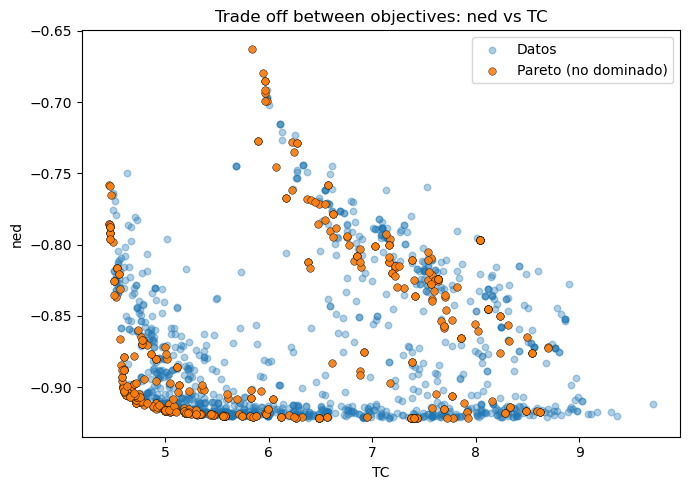

Guardado en: Datos/Transformados\Optimizacion\eda\figures\scatter_TC_vs_ned.png


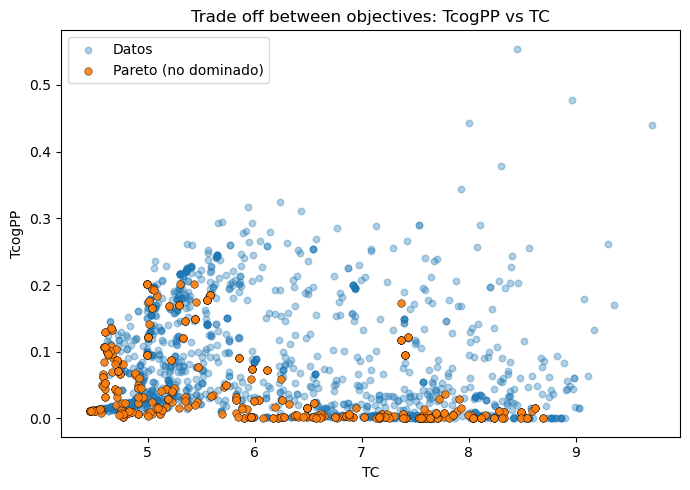

Guardado en: Datos/Transformados\Optimizacion\eda\figures\scatter_TC_vs_TcogPP.png


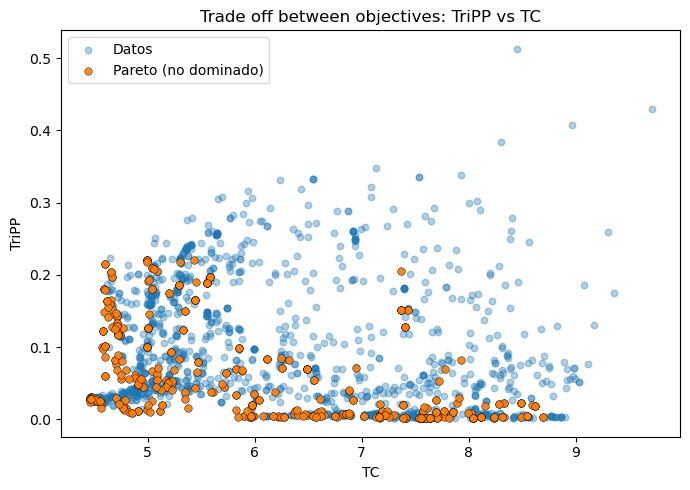

Guardado en: Datos/Transformados\Optimizacion\eda\figures\scatter_TC_vs_TriPP.png


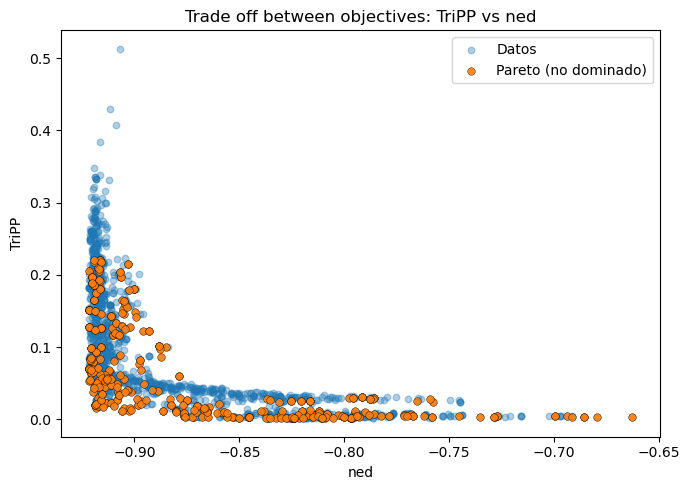

Guardado en: Datos/Transformados\Optimizacion\eda\figures\scatter_ned_vs_TriPP.png


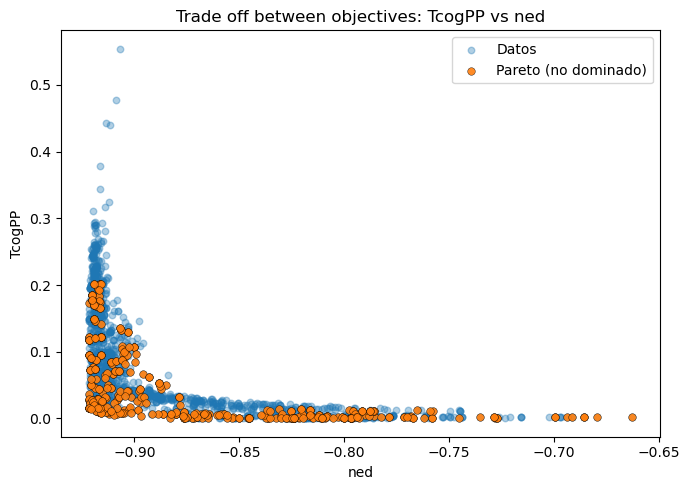

Guardado en: Datos/Transformados\Optimizacion\eda\figures\scatter_ned_vs_TcogPP.png


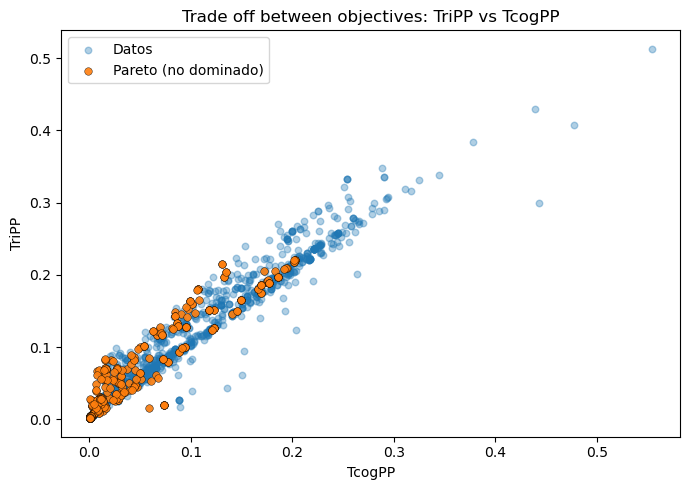

Guardado en: Datos/Transformados\Optimizacion\eda\figures\scatter_TcogPP_vs_TriPP.png


In [10]:
def scatter_con_pareto(df_todos, df_pareto, x, y, dir_figuras, nombre_archivo=None, n_muestra=2000):
    df_graf = df_todos.copy()
    
    if len(df_graf) > n_muestra:
        df_graf = df_graf.sample(n_muestra, random_state=RANDOM_SEED)

    plt.figure(figsize=(7, 5))
    plt.scatter(df_graf[x].values, df_graf[y].values, s=22, alpha=0.35, label="Datos")
    plt.scatter(
        df_pareto[x].values,
        df_pareto[y].values,
        s=30,
        alpha=0.90,
        edgecolors="k",
        linewidths=0.3,
        label="Pareto (no dominado)"
    )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Trade off between objectives: {y} vs {x}")
    plt.legend()
    plt.tight_layout()

    if nombre_archivo is None:
        nombre_archivo = f"scatter_{x}_vs_{y}.png"

    ruta = os.path.join(dir_figuras, nombre_archivo)
    plt.savefig(ruta, dpi=200, bbox_inches="tight")
    plt.show()
    print("Guardado en:", ruta)


pares = [
    ("TC", "ned"),
    ("TC", "TcogPP"),
    ("TC", "TriPP"),
    ("ned", "TriPP"),
    ("ned", "TcogPP"),
    ("TcogPP", "TriPP"),
]

for x, y in pares:
    scatter_con_pareto(df_xy, pareto_df, x=x, y=y, dir_figuras=FIG_DIR, n_muestra=1700)

## 8) Baseline: TOPSIS (para comparar con MOEA)


In [11]:
def topsis_rank(Y: np.ndarray, pesos=None, eps=1e-12):
    """
    Método TOPSIS para criterios de coste (minimización).
    Devuelve un score donde mayor = mejor solución.
    """
    n, m = Y.shape

    if pesos is None:
        pesos = np.ones(m) / m

    pesos = np.asarray(pesos, dtype=float)
    pesos = pesos / (pesos.sum() + eps)

    # Normalización vectorial
    denominador = np.sqrt((Y**2).sum(axis=0)) + eps
    R = Y / denominador

    # Aplicar pesos
    V = R * pesos

    # Solución ideal y anti-ideal (minimización)
    ideal = V.min(axis=0)
    anti_ideal = V.max(axis=0)

    # Distancias
    dist_ideal = np.sqrt(((V - ideal)**2).sum(axis=1))
    dist_anti = np.sqrt(((V - anti_ideal)**2).sum(axis=1))

    # Score TOPSIS
    score = dist_anti / (dist_ideal + dist_anti + eps)

    return score


# =========================
# Ranking TOPSIS del dataset
# =========================

Y_obj = df_xy[Y_cols].values

scores = topsis_rank(Y_obj, pesos=[0.25, 0.25, 0.25, 0.25])

df_baseline = df_xy.copy()
df_baseline["topsis_score"] = scores

df_ordenado = df_baseline.sort_values("topsis_score", ascending=False)

top5_baseline = df_ordenado.head(5).copy()

display(top5_baseline[X_cols + Y_cols + ["topsis_score"]])

ruta_top5 = os.path.join(OUT_DIR, "top5_baseline_topsis.csv")
top5_baseline.to_csv(ruta_top5, index=False)

print("Saved:", ruta_top5)

,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,topsis_score
860,1.2,0.7,1.2,1.0,46.0,4.7,4.827545,0.008444,-0.870609,0.010333,0.979892
481,1.2,0.7,0.7,0.9,47.0,5.1,4.912502,0.007127,-0.880182,0.011445,0.979719
318,1.2,0.7,0.7,0.9,47.0,5.1,4.912502,0.007127,-0.880182,0.011445,0.979719
44,1.2,0.7,0.7,0.9,47.0,5.1,4.912502,0.007127,-0.880182,0.011445,0.979719
1246,1.2,0.7,0.8,1.0,46.0,4.7,4.858440,0.009889,-0.876492,0.008818,0.979661


Saved: Datos/Transformados\Optimizacion\eda\top5_baseline_topsis.csv


## 9) Resumen  

In [12]:
summary = {
    "n_rows_raw": int(df_raw.shape[0]),
    "n_rows_clean": int(df_xy.shape[0]),
    "n_pareto": int(pareto_df.shape[0]),
    "pareto_ratio": float(pareto_df.shape[0] / max(df_xy.shape[0], 1)),
    "X_cols": X_cols,
    "Y_cols": Y_cols,
    "nota": "Objetivos tratados como minimización; 'ned' corresponde a -eta (eficiencia negada)."
}

summary_path = os.path.join(OUT_DIR, "eda_resumen.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", summary_path)
summary

Saved: Datos/Transformados\Optimizacion\eda\eda_resumen.json


{'n_rows_raw': 1700,
 'n_rows_clean': 1700,
 'n_pareto': 410,
 'pareto_ratio': 0.2411764705882353,
 'X_cols': ['hm', 'alpha_m', 'er', 'dsi', 'bst', 'bss'],
 'Y_cols': ['TC', 'TcogPP', 'ned', 'TriPP'],
 'nota': "Objetivos tratados como minimización; 'ned' corresponde a -eta (eficiencia negada)."}

In [13]:
# Comprobación de calidad de datos sin eliminar duplicados
tmp = df[X_cols + Y_cols].replace([np.inf, -np.inf], np.nan)

print("Filas con NaN:", tmp.isna().any(axis=1).sum())
print("Duplicados exactos:", tmp.dropna().duplicated().sum())
print("Filas totales originales:", len(tmp))
print("Filas limpias manteniendo duplicados:", len(df_xy))

Filas con NaN: 0
Duplicados exactos: 395
Filas totales originales: 1700
Filas limpias manteniendo duplicados: 1700


In [14]:
clean_path = os.path.join(OUT_DIR, "dataset_clean.csv")
df_xy.to_csv(clean_path, index=False)

print("Saved clean dataset:", clean_path)

Saved clean dataset: Datos/Transformados\Optimizacion\eda\dataset_clean.csv


In [15]:
# =========================
# Comprobar si TOP5 está en Pareto
# =========================

# Marcar si cada punto del dataset está en Pareto
pareto_set = set(pareto_df.index)

top5_baseline["is_pareto"] = top5_baseline.index.isin(pareto_set)

print("TOP5 baseline pertenece a Pareto:")
display(top5_baseline[["is_pareto"]])

n_pareto = top5_baseline["is_pareto"].sum()

print(f"\nSoluciones TOP5 en Pareto: {n_pareto}/5")

TOP5 baseline pertenece a Pareto:


,is_pareto
860,True
481,True
318,True
44,True
1246,True



Soluciones TOP5 en Pareto: 5/5
